In this notebook, we applied all Kalman Filters using IMU, Voxl Vehicle Odometry and GPS data corrected by the PX4 drone.

In [1]:
import sys
sys.path.append('/app/src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from utils.error_report import get_error_from_list, get_error_report, print_error_report
from utils import lla_to_ned

from data_loader import UAV_DataLoader
from configs.configs import SetupEnum, ErrorEnum
from kalman_filters import (
    ExtendedKalmanFilter,
    UnscentedKalmanFilter,
    ParticleFilter, ResamplingAlgorithms,
    EnsembleKalmanFilter,
    CubatureKalmanFilter
)

%matplotlib inline
np.random.seed(777)

In [2]:
root_path = "../../../data"

loader = UAV_DataLoader(root_path=root_path, sequence_nr="log0001")

plt_config = {
    'xlim': (-30, 15),
    'ylim': (-30, 10),
    'zlim': (-300, 0)
}

VO estimate data not found.
UWB position data not found.


In [3]:
loader.ref_df['device'].value_counts()

device
voxl_imu1           86052
voxl_imu0           76667
px4_imu1            15390
px4_imu0            15386
px4_vehicle_odom     5498
voxl_vo              2280
px4_vo               1647
px4_gps               440
px4_imu1_bias         265
px4_imu0_bias         242
Name: count, dtype: int64

In [4]:
# IMU + GPS + Vehcile Odometory
df1 = loader.ref_df.loc[
                (loader.ref_df["device"] == "voxl_imu0") | 
                (loader.ref_df["device"] == "px4_vehicle_odom") |
                (loader.ref_df["device"] == "px4_gps")]
# IMU + GPS + Vehicle Visual Odometory
df2 = loader.ref_df.loc[
                (loader.ref_df["device"] == "voxl_imu0") | 
                (loader.ref_df["device"] == "px4_vo") |
                (loader.ref_df["device"] == "px4_gps")]

In [5]:
df1["device"].value_counts()

device
voxl_imu0           76667
px4_vehicle_odom     5498
px4_gps               440
Name: count, dtype: int64

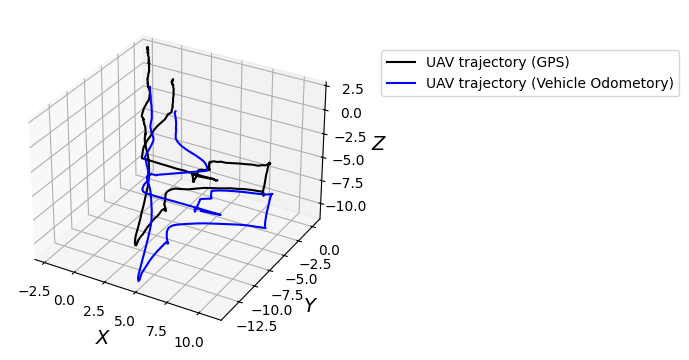

In [7]:
t_last = df1.iloc[0]['timestamp']
df_reference = loader.get_config(timestamp=t_last)

fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
x, y, z = loader.px4_gps_df[loader.gps_ned_pose_columns].values.T
ax1.plot(x, y, z, label='UAV trajectory (GPS)', color='black')
x, y, z = df_reference['px4_vehicle_odom']['df'][loader.vo_pos_columns].values.T
ax1.plot(x, y, z, label='UAV trajectory (Vehicle Odometory)', color='blue')

ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)


ax1.legend(loc='best', bbox_to_anchor=(1.1, 0., 0.2, 0.9))
fig.tight_layout()
plt.show()

### EKF

In [8]:
x = np.array([
    [loader.px4_gps_df.iloc[0]['north']],
    [loader.px4_gps_df.iloc[0]['east']],
    [loader.px4_gps_df.iloc[0]['down']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.01, 0.01, 0.01, 0.0035, 0.0035, 0.0035])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

In [9]:
ekf = ExtendedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1
)

ekf_imu_gps = ExtendedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1
)

In [10]:
t_last = df1.iloc[0]['timestamp']
df_reference = loader.get_config(timestamp=t_last)
original_position = loader.px4_gps_df[loader.gps_pose_columns].iloc[0].values #ned pose

ekf_mu_x = [x[0][0]]
ekf_mu_y = [x[1][0]]
ekf_mu_z = [x[2][0]]

ekf_imu_gps_mu_x = [x[0][0]]
ekf_imu_gps_mu_y = [x[1][0]]
ekf_imu_gps_mu_z = [x[2][0]]

N = len(df1.values)
for idx in tqdm(range(0, N)):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000

    if dt < loader.SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in loader.time_update:
            # Call Time update step
            ekf.predict_setup1_2(u=data.values, dt=dt, Q=ekf.Q)
            ekf_imu_gps.predict_setup1_2(u=data.values, dt=dt, Q=ekf_imu_gps.Q)
            
        elif data_ref['device'] in loader.measurement_update:
            # Call Measurement update step
            if data_ref['device'] == 'px4_gps':
                x_hat = ekf.x.copy()
                ekf_mu_x.append(x_hat[0, 0])
                ekf_mu_y.append(x_hat[1, 0])
                ekf_mu_z.append(x_hat[2, 0])
                x_hat2 = ekf_imu_gps.x.copy()
                ekf_imu_gps_mu_x.append(x_hat2[0, 0])
                ekf_imu_gps_mu_y.append(x_hat2[1, 0])
                ekf_imu_gps_mu_z.append(x_hat2[2, 0])
                
                gps_ned = lla_to_ned(
                    data[loader.gps_pose_columns].values.reshape(-1, 1),
                    original_position
                ).T[0]
                z_gps = np.array([
                    gps_ned[0],
                    gps_ned[1],
                    gps_ned[2],
                ])
                r_gps = data[loader.gps_pos_var_columns].values ** 2
                R_gps = np.eye(H.shape[0]) * r_gps
                ekf.update(z=z_gps, R=R_gps)            
                
                ekf_imu_gps.update(z=z, R=R_gps)
                
            elif data_ref['device'] == 'px4_vehicle_odom':
                z_vo = data[loader.vo_pos_columns].values
                r_vo = data[loader.vo_pos_var_columns].values ** 2
                if np.isnan(r_vo.sum()):
                    R_vo = ekf.R_vo
                else:
                    R_vo = np.eye(r_vo.shape[0]) * r_vo
                
                ekf.update(z=z_vo, R=R_vo)
                
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1


ekf_mu_x = np.array(ekf_mu_x)
ekf_mu_y = np.array(ekf_mu_y)
ekf_mu_z = np.array(ekf_mu_z)

ekf_imu_gps_mu_x = np.array(ekf_imu_gps_mu_x)
ekf_imu_gps_mu_y = np.array(ekf_imu_gps_mu_y)
ekf_imu_gps_mu_z = np.array(ekf_imu_gps_mu_z)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 82605/82605 [01:00<00:00, 1363.84it/s]


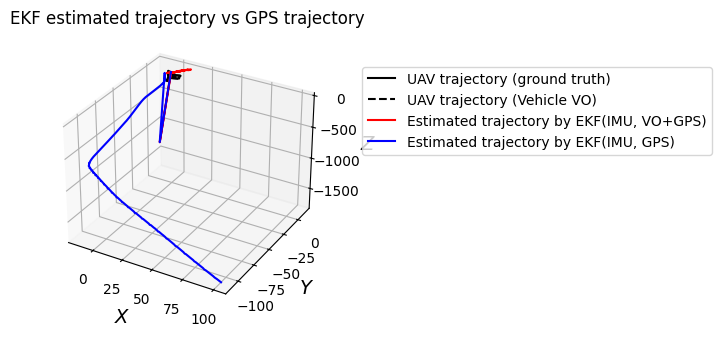

In [11]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("EKF estimated trajectory vs GPS trajectory")

ax1.plot(loader.px4_gps_df['north'].values, 
         loader.px4_gps_df['east'].values, 
         loader.px4_gps_df['down'].values, 
         label='UAV trajectory (ground truth)', 
         color='black')

x, y, z = df_reference['px4_vehicle_odom']['df'][loader.vo_pos_columns].values.T
ax1.plot(x, y, z, label='UAV trajectory (Vehicle VO)', color='black', linestyle='dashed')

ax1.plot(ekf_mu_x, ekf_mu_y, ekf_mu_z, label='Estimated trajectory by EKF(IMU, VO+GPS)', color='red')
ax1.plot(ekf_imu_gps_mu_x, ekf_imu_gps_mu_y, ekf_imu_gps_mu_z, label='Estimated trajectory by EKF(IMU, GPS)', color='blue')

ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)

# ax1.set_xlim(plt_config['xlim'])
# ax1.set_ylim(plt_config['ylim'])
# ax1.set_zlim(plt_config['zlim'])

ax1.legend(loc='best', bbox_to_anchor=(1.1, 0., 0.2, 0.9))
fig.tight_layout()
plt.show()

In [12]:
ekf_imu_vo_gps_error = get_error_report(loader.px4_gps_df[loader.gps_ned_pose_columns].values, 
                            np.array([ekf_mu_x, ekf_mu_y, ekf_mu_z]).T)
ekf_imu_gps_error = get_error_report(loader.px4_gps_df[loader.gps_ned_pose_columns].values, 
                            np.array([ekf_imu_gps_mu_x, ekf_imu_gps_mu_y, ekf_imu_gps_mu_z]).T)

print_error_report(
    report=ekf_imu_vo_gps_error,
    title="Deviation between EKF(IMU, VO+GPS) estimated pose and GPS"
)

print_error_report(
    report=ekf_imu_gps_error,
    title="Deviation between EKF(IMU, GPS) estimated pose and GPS"
)


----- Deviation between EKF(IMU, VO+GPS) estimated pose and GPS -----
Mean Absolute Error: 5.322 m
Root Mean Squared Error: 34.331 m
Maximum Error: 1224.167 m
---------------------------------------------------------------------


----- Deviation between EKF(IMU, GPS) estimated pose and GPS -----
Mean Absolute Error: 245.797 m
Root Mean Squared Error: 498.427 m
Maximum Error: 1798.026 m
------------------------------------------------------------------



### UKF

In [13]:
x = np.array([
    [loader.px4_gps_df.iloc[0]['north']],
    [loader.px4_gps_df.iloc[0]['east']],
    [loader.px4_gps_df.iloc[0]['down']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

alpha_setup = 10.
beta_setup = 2.
kappa_setup = 0.

ukf = UnscentedKalmanFilter(
    x=x.copy(), 
    P=P.copy(),
    H=H.copy(), 
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    alpha=alpha_setup, 
    beta=beta_setup, 
    kappa=kappa_setup,
    setup=SetupEnum.SETUP_1
)

ukf_imu_gps = UnscentedKalmanFilter(
    x=x.copy(), 
    P=P.copy(),
    H=H.copy(), 
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    alpha=alpha_setup, 
    beta=beta_setup, 
    kappa=kappa_setup,
    setup=SetupEnum.SETUP_1
)

In [14]:
t_last = df1.iloc[0]['timestamp']
df_reference = loader.get_config(timestamp=t_last)
original_position = loader.px4_gps_df[loader.gps_pose_columns].iloc[0].values

ukf_mu_x = [x[0][0]]
ukf_mu_y = [x[1][0]]
ukf_mu_z = [x[2][0]]

ukf_imu_gps_mu_x = [x[0][0]]
ukf_imu_gps_mu_y = [x[1][0]]
ukf_imu_gps_mu_z = [x[2][0]]

N = len(df1.values)
for idx in tqdm(range(0, N)):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000

    if dt < loader.SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in loader.time_update:
            # Call Time update step
            ukf.predict_setup1_2(u=data.values, dt=dt, Q=ukf.Q)
            ukf_imu_gps.predict_setup1_2(u=data.values, dt=dt, Q=ukf_imu_gps.Q)
            
        elif data_ref['device'] in loader.measurement_update:
            # Call Measurement update step
            if data_ref['device'] == 'px4_gps':
                x_hat = ukf.x.copy()
                ukf_mu_x.append(x_hat[0, 0])
                ukf_mu_y.append(x_hat[1, 0])
                ukf_mu_z.append(x_hat[2, 0])
                
                x_hat2 = ukf_imu_gps.x.copy()
                ukf_imu_gps_mu_x.append(x_hat2[0, 0])
                ukf_imu_gps_mu_y.append(x_hat2[1, 0])
                ukf_imu_gps_mu_z.append(x_hat2[2, 0])
                
                gps_ned = lla_to_ned(
                    data[loader.gps_pose_columns].values.reshape(-1, 1),
                    original_position
                ).T[0]
                z_gps = np.array([
                    gps_ned[0],
                    gps_ned[1],
                    gps_ned[2],
                ])
                r_gps = data[loader.gps_pos_var_columns].values ** 2
                R_gps = np.eye(H.shape[0]) * r_gps
                
                ukf.update(z=z_gps, R=R_gps)

                ukf_imu_gps.update(z=z_gps, R=R_gps)
                
            elif data_ref['device'] == 'px4_vehicle_odom':
                z_vo = data[loader.vo_pos_columns].values
                r_vo = data[loader.vo_pos_var_columns].values ** 2
                if np.isnan(r_vo.sum()):
                    R_vo = ukf.R_vo
                else:
                    R_vo = np.eye(r_vo.shape[0]) * r_vo
                ukf.update(z=z_vo, R=R_vo)

    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1

ukf_mu_x = np.array(ukf_mu_x)
ukf_mu_y = np.array(ukf_mu_y)
ukf_mu_z = np.array(ukf_mu_z)

ukf_imu_gps_mu_x = np.array(ukf_imu_gps_mu_x)
ukf_imu_gps_mu_y = np.array(ukf_imu_gps_mu_y)
ukf_imu_gps_mu_z = np.array(ukf_imu_gps_mu_z)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 82605/82605 [01:04<00:00, 1288.47it/s]


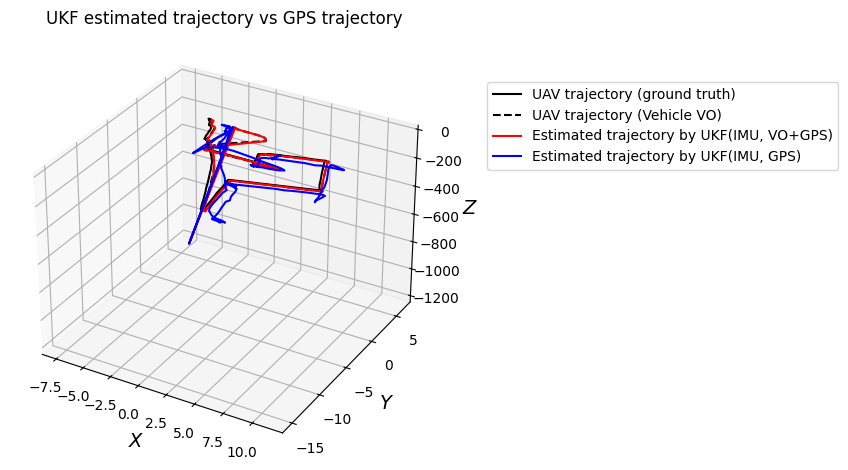

In [15]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("UKF estimated trajectory vs GPS trajectory")

ax1.plot(loader.px4_gps_df['north'].values, 
         loader.px4_gps_df['east'].values, 
         loader.px4_gps_df['down'].values, 
         label='UAV trajectory (ground truth)', 
         color='black')

x, y, z = df_reference['px4_vehicle_odom']['df'][loader.vo_pos_columns].values.T
ax1.plot(x, y, z, label='UAV trajectory (Vehicle VO)', color='black', linestyle='dashed')

ax1.plot(ukf_mu_x, ukf_mu_y, ukf_mu_z, label='Estimated trajectory by UKF(IMU, VO+GPS)', color='red')
ax1.plot(ukf_imu_gps_mu_x, ukf_imu_gps_mu_y, ukf_imu_gps_mu_z, label='Estimated trajectory by UKF(IMU, GPS)', color='blue')

ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)

# ax1.set_xlim(plt_config['xlim'])
# ax1.set_ylim(plt_config['ylim'])
# ax1.set_zlim(plt_config['zlim'])

fig.tight_layout()
ax1.legend(loc='best', bbox_to_anchor=(1.1, 0., 0.2, 0.9))
plt.show()

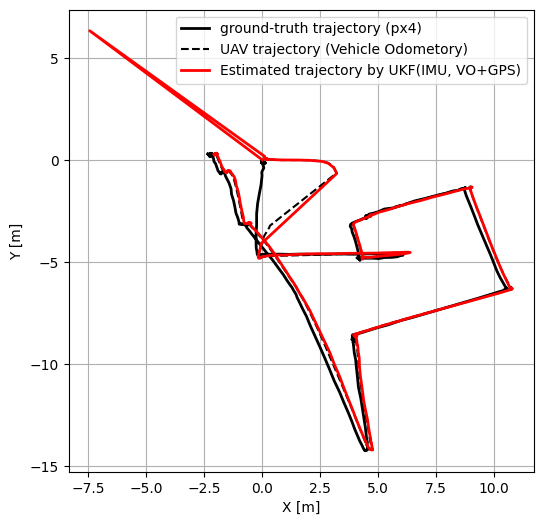

In [16]:
fig, ax1 = plt.subplots(1, 1, figsize=(6, 6))
x, y = loader.px4_gps_df[['north', 'east']].values.T
ax1.plot(x, y, lw=2, label='ground-truth trajectory (px4)', color='black')

x, y, _ = df_reference['px4_vehicle_odom']['df'][loader.vo_pos_columns].values.T
ax1.plot(x, y, label='UAV trajectory (Vehicle Odometory)', color='black', linestyle='dashed')

ax1.plot(ukf_mu_x, ukf_mu_y, lw=2, label='Estimated trajectory by UKF(IMU, VO+GPS)', color='red')
ax1.set_xlabel('X [m]')
ax1.set_ylabel('Y [m]')
ax1.legend()
ax1.grid()

In [17]:
ukf_imu_vo_gps_error = get_error_report(loader.px4_gps_df[loader.gps_ned_pose_columns].values, 
                            np.array([ukf_mu_x, ukf_mu_y, ukf_mu_z]).T)
ukf_imu_gps_error = get_error_report(loader.px4_gps_df[loader.gps_ned_pose_columns].values, 
                            np.array([ukf_imu_gps_mu_x, ukf_imu_gps_mu_y, ukf_imu_gps_mu_z]).T)

print_error_report(
    report=ukf_imu_vo_gps_error,
    title="Deviation between UKF(IMU, VO+GPS) estimated pose and GPS"
)

print_error_report(
    report=ukf_imu_gps_error,
    title="Deviation between UKF(IMU, GPS) estimated pose and GPS"
)


----- Deviation between UKF(IMU, VO+GPS) estimated pose and GPS -----
Mean Absolute Error: 2.425 m
Root Mean Squared Error: 33.704 m
Maximum Error: 1221.325 m
---------------------------------------------------------------------


----- Deviation between UKF(IMU, GPS) estimated pose and GPS -----
Mean Absolute Error: 5.061 m
Root Mean Squared Error: 39.629 m
Maximum Error: 1221.325 m
------------------------------------------------------------------



### PF

In [20]:
x = np.array([
    [loader.px4_gps_df.iloc[0]['north']],
    [loader.px4_gps_df.iloc[0]['east']],
    [loader.px4_gps_df.iloc[0]['down']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

importance_resampling = True

pf = ParticleFilter(
    N=2048, 
    x_dim=x.shape[0], 
    H=H.copy(), 
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1,
    resampling_algorithm=ResamplingAlgorithms.STRATIFIED)
pf.create_gaussian_particles(mean=x.copy(), var=P.copy())

pf_imu_gps = ParticleFilter(
    N=2048, 
    x_dim=x.shape[0], 
    H=H.copy(), 
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1,
    resampling_algorithm=ResamplingAlgorithms.STRATIFIED)
pf_imu_gps.create_gaussian_particles(mean=x.copy(), var=P.copy())

In [21]:
t_last = df1.iloc[0]['timestamp']
df_reference = loader.get_config(timestamp=t_last)
original_position = loader.px4_gps_df[loader.gps_pose_columns].iloc[0].values

pf_mu_x = [x[0][0]]
pf_mu_y = [x[1][0]]
pf_mu_z = [x[2][0]]

pf_imu_gps_mu_x = [x[0][0]]
pf_imu_gps_mu_y = [x[1][0]]
pf_imu_gps_mu_z = [x[2][0]]

N = len(df1.values)
for idx in tqdm(range(0, N)):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000

    if dt < loader.SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in loader.time_update:
            # Call Time update step
            pf.predict_setup1_2(u=data.values, dt=dt, Q=pf.Q)
            pf_imu_gps.predict_setup1_2(u=data.values, dt=dt, Q=pf_imu_gps.Q)
            
        elif data_ref['device'] in loader.measurement_update:
            # Call Measurement update step
            if data_ref['device'] == 'px4_gps':
                x_hat, _ = pf.estimate()
                pf_mu_x.append(x_hat[0])
                pf_mu_y.append(x_hat[1])
                pf_mu_z.append(x_hat[2])
                
                x_hat2, _ = pf_imu_gps.estimate()
                pf_imu_gps_mu_x.append(x_hat2[0])
                pf_imu_gps_mu_y.append(x_hat2[1])
                pf_imu_gps_mu_z.append(x_hat2[2])

                
                gps_ned = lla_to_ned(
                    data[loader.gps_pose_columns].values.reshape(-1, 1),
                    original_position
                ).T[0]
                z_gps = np.array([
                    gps_ned[0],
                    gps_ned[1],
                    gps_ned[2],
                ])
                r_gps = data[loader.gps_pos_var_columns].values ** 2
                R_gps = np.eye(H.shape[0]) * r_gps
                
                pf.update(z=z_gps, R=R_gps)
                
                pf_imu_gps.update(z=z_gps, R=R_gps)
                
            elif data_ref['device'] == 'px4_vehicle_odom':
                z_vo = data[loader.vo_pos_columns].values
                r_vo = data[loader.vo_pos_var_columns].values ** 2
                if np.isnan(r_vo.sum()):
                    R_vo = pf.R_vo
                else:
                    R_vo = np.eye(r_vo.shape[0]) * r_vo
                
                pf.update(z=z_vo, R=R_vo)
                
            if pf._allow_resampling(importance_resampling=importance_resampling):
                pf.resample()

    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1


pf_mu_x = np.array(pf_mu_x)
pf_mu_y = np.array(pf_mu_y)
pf_mu_z = np.array(pf_mu_z)

pf_imu_gps_mu_x = np.array(pf_imu_gps_mu_x)
pf_imu_gps_mu_y = np.array(pf_imu_gps_mu_y)
pf_imu_gps_mu_z = np.array(pf_imu_gps_mu_z)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 82605/82605 [46:33<00:00, 29.58it/s]


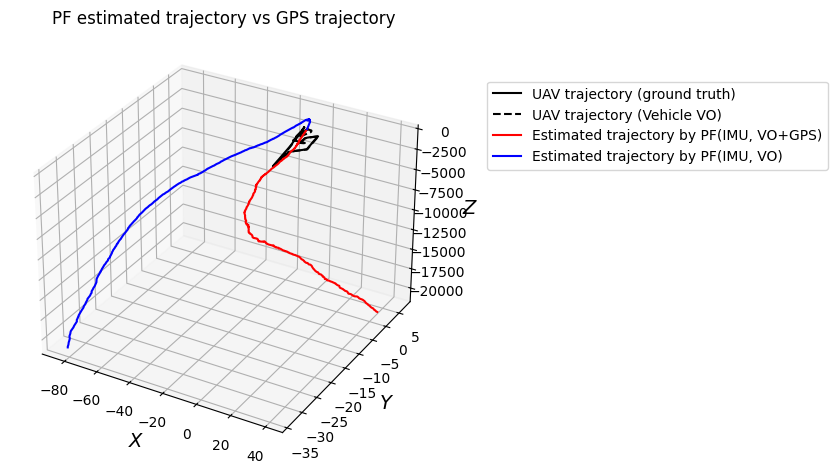

In [22]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("PF estimated trajectory vs GPS trajectory")

ax1.plot(loader.px4_gps_df['north'].values, 
         loader.px4_gps_df['east'].values, 
         loader.px4_gps_df['down'].values, 
         label='UAV trajectory (ground truth)', 
         color='black')

x, y, z = df_reference['px4_vehicle_odom']['df'][loader.vo_pos_columns].values.T
ax1.plot(x, y, z, label='UAV trajectory (Vehicle VO)', color='black', linestyle='dashed')

ax1.plot(pf_mu_x, pf_mu_y, pf_mu_z, label='Estimated trajectory by PF(IMU, VO+GPS)', color='red')
ax1.plot(pf_imu_gps_mu_x, pf_imu_gps_mu_y, pf_imu_gps_mu_z, label='Estimated trajectory by PF(IMU, VO)', color='blue')

ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)

# ax1.set_xlim(plt_config['xlim'])
# ax1.set_ylim(plt_config['ylim'])
# ax1.set_zlim(plt_config['zlim'])

fig.tight_layout()
ax1.legend(loc='best', bbox_to_anchor=(1.1, 0., 0.2, 0.9))
plt.show()

In [23]:
pf_imu_vo_gps_error = get_error_report(loader.px4_gps_df[loader.gps_ned_pose_columns].values, 
                            np.array([pf_mu_x, pf_mu_y, pf_mu_z]).T)
pf_imu_gps_error = get_error_report(loader.px4_gps_df[loader.gps_ned_pose_columns].values, 
                            np.array([pf_imu_gps_mu_x, pf_imu_gps_mu_y, pf_imu_gps_mu_z]).T)

print_error_report(
    report=pf_imu_vo_gps_error,
    title="Deviation between PF(IMU, VO+GPS) estimated pose and GPS"
)

print_error_report(
    report=pf_imu_gps_error,
    title="Deviation between PF(IMU, GPS) estimated pose and GPS"
)


----- Deviation between PF(IMU, VO+GPS) estimated pose and GPS -----
Mean Absolute Error: 2838.978 m
Root Mean Squared Error: 6041.355 m
Maximum Error: 21323.089 m
--------------------------------------------------------------------


----- Deviation between PF(IMU, GPS) estimated pose and GPS -----
Mean Absolute Error: 2851.419 m
Root Mean Squared Error: 6030.956 m
Maximum Error: 21294.814 m
-----------------------------------------------------------------



### EnKF

In [24]:
x = np.array([
    [loader.px4_gps_df.iloc[0]['north']],
    [loader.px4_gps_df.iloc[0]['east']],
    [loader.px4_gps_df.iloc[0]['down']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

n_ensemble = 64
enkf = EnsembleKalmanFilter(
    N=n_ensemble, 
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1)

enkf_imu_gps = EnsembleKalmanFilter(
    N=n_ensemble, 
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1)
    

In [25]:
t_last = df1.iloc[0]['timestamp']
df_reference = loader.get_config(timestamp=t_last)
original_position = loader.px4_gps_df[loader.gps_pose_columns].iloc[0].values

enkf_mu_x = [x[0][0]]
enkf_mu_y = [x[1][0]]
enkf_mu_z = [x[2][0]]

enkf_imu_gps_mu_x = [x[0][0]]
enkf_imu_gps_mu_y = [x[1][0]]
enkf_imu_gps_mu_z = [x[2][0]]

for idx in tqdm(range(0, df1.shape[0])):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000
    
    if dt < loader.SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in loader.time_update:
            # Call Time update step
            enkf.predict_setup1_2(u=data.values, dt=dt, Q=enkf.Q)
            enkf_imu_gps.predict_setup1_2(u=data.values, dt=dt, Q=enkf_imu_gps.Q)

        elif data_ref['device'] in loader.measurement_update:
            # Call Measurement update step
            if data_ref['device'] == 'px4_gps':
                x_hat = enkf.x.copy()
                enkf_mu_x.append(x_hat[0])
                enkf_mu_y.append(x_hat[1])
                enkf_mu_z.append(x_hat[2])
                x_hat2 = enkf_imu_gps.x.copy()
                enkf_imu_gps_mu_x.append(x_hat2[0])
                enkf_imu_gps_mu_y.append(x_hat2[1])
                enkf_imu_gps_mu_z.append(x_hat2[2])

                gps_ned = lla_to_ned(
                    data[loader.gps_pose_columns].values.reshape(-1, 1),
                    original_position
                ).T[0]
                z_gps = np.array([
                    gps_ned[0],
                    gps_ned[1],
                    gps_ned[2],
                ])
                r_gps = data[loader.gps_pos_var_columns].values ** 2
                R_gps = np.eye(H.shape[0]) * r_gps
                
                enkf.update(z=z_gps, R=R_gps)
                enkf_imu_gps.update(z=z_gps, R=R_gps)
    
            elif data_ref['device'] == 'px4_vehicle_odom':
                z_vo = data[loader.vo_pos_columns].values
                r_vo = data[loader.vo_pos_var_columns].values ** 2
                if np.isnan(r_vo.sum()):
                    R_vo = enkf.R_vo
                else:
                    R_vo = np.eye(r_vo.shape[0]) * r_vo
                
                enkf.update(z=z_vo, R=R_vo)
                
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1


enkf_mu_x = np.array(enkf_mu_x)
enkf_mu_y = np.array(enkf_mu_y)
enkf_mu_z = np.array(enkf_mu_z)

enkf_imu_gps_mu_x = np.array(enkf_imu_gps_mu_x)
enkf_imu_gps_mu_y = np.array(enkf_imu_gps_mu_y)
enkf_imu_gps_mu_z = np.array(enkf_imu_gps_mu_z)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 82605/82605 [01:44<00:00, 790.41it/s]


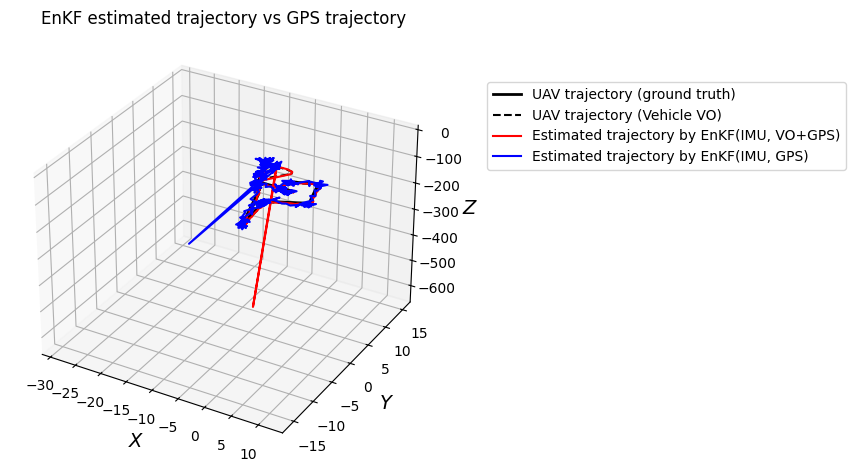

In [26]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("EnKF estimated trajectory vs GPS trajectory")

ax1.plot(loader.px4_gps_df['north'].values, 
         loader.px4_gps_df['east'].values, 
         loader.px4_gps_df['down'].values, 
         label='UAV trajectory (ground truth)', 
         color='black', lw=2)
x, y, z = df_reference['px4_vehicle_odom']['df'][loader.vo_pos_columns].values.T
ax1.plot(x, y, z, label='UAV trajectory (Vehicle VO)', color='black', linestyle='dashed')


ax1.plot(enkf_mu_x, enkf_mu_y, enkf_mu_z, label='Estimated trajectory by EnKF(IMU, VO+GPS)', color='red')
ax1.plot(enkf_imu_gps_mu_x, 
         enkf_imu_gps_mu_y, 
         enkf_imu_gps_mu_z, 
         label='Estimated trajectory by EnKF(IMU, GPS)', 
         color='blue')

ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)

# ax1.set_xlim(plt_config['xlim'])
# ax1.set_ylim(plt_config['ylim'])
# ax1.set_zlim(plt_config['zlim'])

fig.tight_layout()
ax1.legend(loc='best', bbox_to_anchor=(1.1, 0., 0.2, 0.9))
plt.show()

In [27]:
enkf_imu_vo_gps_error = get_error_report(loader.px4_gps_df[loader.gps_ned_pose_columns].values, 
                            np.array([enkf_mu_x, enkf_mu_y, enkf_mu_z]).T)
enkf_imu_gps_error = get_error_report(loader.px4_gps_df[loader.gps_ned_pose_columns].values, 
                            np.array([enkf_imu_gps_mu_x, enkf_imu_gps_mu_y, enkf_imu_gps_mu_z]).T)

print_error_report(
    report=enkf_imu_vo_gps_error,
    title="Deviation between EnKF(IMU, VO+GPS) estimated pose and GPS"
)

print_error_report(
    report=enkf_imu_gps_error,
    title="Deviation between EnKF(IMU, GPS) estimated pose and GPS"
)


----- Deviation between EnKF(IMU, VO+GPS) estimated pose and GPS -----
Mean Absolute Error: 1.882 m
Root Mean Squared Error: 15.414 m
Maximum Error: 553.44 m
----------------------------------------------------------------------


----- Deviation between EnKF(IMU, GPS) estimated pose and GPS -----
Mean Absolute Error: 1.366 m
Root Mean Squared Error: 17.991 m
Maximum Error: 651.621 m
-------------------------------------------------------------------



### CKF

In [28]:
x = np.array([
    [loader.px4_gps_df.iloc[0]['north']],
    [loader.px4_gps_df.iloc[0]['east']],
    [loader.px4_gps_df.iloc[0]['down']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r_gps = np.array([0.1, 0.1, 0.1])
r_vo_default = np.array([0.1, 0.1, 0.1])

ckf = CubatureKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1,
)

ckf_imu_gps = CubatureKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=r_vo_default,
    r_gps=r_gps,
    setup=SetupEnum.SETUP_1,
)

In [29]:
t_last = df1.iloc[0]['timestamp']
df_reference = loader.get_config(timestamp=t_last)
original_position = loader.px4_gps_df[loader.gps_pose_columns].iloc[0].values

ckf_mu_x = [x[0][0]]
ckf_mu_y = [x[1][0]]
ckf_mu_z = [x[2][0]]

ckf_imu_gps_mu_x = [x[0][0]]
ckf_imu_gps_mu_y = [x[1][0]]
ckf_imu_gps_mu_z = [x[2][0]]

for idx in tqdm(range(0, df1.shape[0])):
    data_ref = df1.iloc[idx]
    sensor = df_reference[data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000
    
    if dt < loader.SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in loader.time_update:
            # Call Time update step
            ckf.predict_setup1_2(u=data.values, dt=dt, Q=ckf.Q)
            ckf_imu_gps.predict_setup1_2(u=data.values, dt=dt, Q=ckf_imu_gps.Q)
    
        elif data_ref['device'] in loader.measurement_update:
            # Call Measurement update step
            if data_ref['device'] == 'px4_gps':
                x_hat = ckf.x.copy()
                ckf_mu_x.append(x_hat[0, 0])
                ckf_mu_y.append(x_hat[1, 0])
                ckf_mu_z.append(x_hat[2, 0])
                x_hat2 = ckf_imu_gps.x.copy()
                ckf_imu_gps_mu_x.append(x_hat2[0, 0])
                ckf_imu_gps_mu_y.append(x_hat2[1, 0])
                ckf_imu_gps_mu_z.append(x_hat2[2, 0])
                
                gps_ned = lla_to_ned(
                    data[loader.gps_pose_columns].values.reshape(-1, 1),
                    original_position
                ).T[0]
                z_gps = np.array([
                    gps_ned[0],
                    gps_ned[1],
                    gps_ned[2],
                ])
                r_gps = data[loader.gps_pos_var_columns].values ** 2
                R_gps = np.eye(H.shape[0]) * r_gps
                
                ckf.update(z=z_gps, R=R_gps)
                
                ckf_imu_gps.update(z=z_gps, R=R_gps)
                
            elif data_ref['device'] == 'px4_vehicle_odom':
                z_vo = data[loader.vo_pos_columns].values
                r_vo = data[loader.vo_pos_var_columns].values ** 2
                if np.isnan(r_vo.sum()):
                    R_vo = ckf.R_vo
                else:
                    R_vo = np.eye(r_vo.shape[0]) * r_vo
                ckf.update(z=z_vo, R=R_vo)
                
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1

ckf_mu_x = np.array(ckf_mu_x)
ckf_mu_y = np.array(ckf_mu_y)
ckf_mu_z = np.array(ckf_mu_z)

ckf_imu_gps_mu_x = np.array(ckf_imu_gps_mu_x)
ckf_imu_gps_mu_y = np.array(ckf_imu_gps_mu_y)
ckf_imu_gps_mu_z = np.array(ckf_imu_gps_mu_z)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 82605/82605 [00:54<00:00, 1525.53it/s]


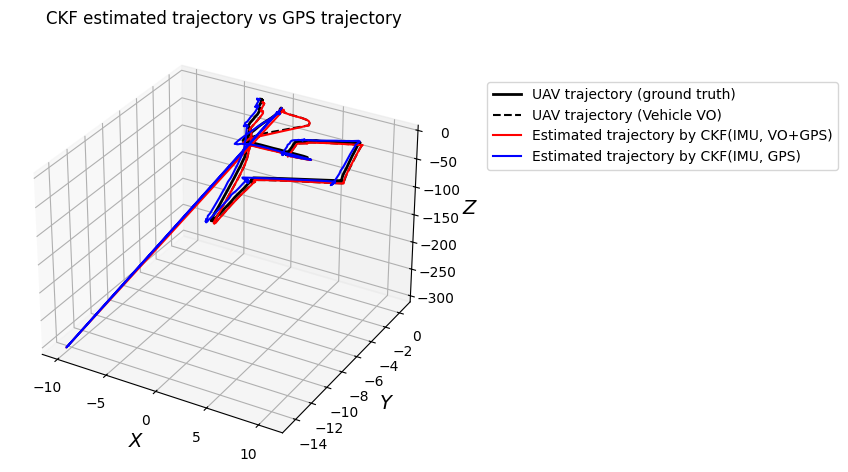

In [30]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("CKF estimated trajectory vs GPS trajectory")

ax1.plot(loader.px4_gps_df['north'].values, 
         loader.px4_gps_df['east'].values, 
         loader.px4_gps_df['down'].values, 
         label='UAV trajectory (ground truth)', 
         color='black', lw=2)
x, y, z = df_reference['px4_vehicle_odom']['df'][loader.vo_pos_columns].values.T
ax1.plot(x, y, z, label='UAV trajectory (Vehicle VO)', color='black', linestyle='dashed')

ax1.plot(ckf_mu_x, ckf_mu_y, ckf_mu_z, label='Estimated trajectory by CKF(IMU, VO+GPS)', color='red')
ax1.plot(ckf_imu_gps_mu_x, ckf_imu_gps_mu_y, ckf_imu_gps_mu_z, label='Estimated trajectory by CKF(IMU, GPS)', color='blue')

ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)

# ax1.set_xlim(plt_config['xlim'])
# ax1.set_ylim(plt_config['ylim'])
# ax1.set_zlim(plt_config['zlim'])

fig.tight_layout()
ax1.legend(loc='best', bbox_to_anchor=(1.1, 0., 0.2, 0.9))
plt.show()

In [31]:
ckf_imu_vo_gps_error = get_error_report(loader.px4_gps_df[loader.gps_ned_pose_columns].values, 
                            np.array([ckf_mu_x, ckf_mu_y, ckf_mu_z]).T)
ckf_imu_gps_error = get_error_report(loader.px4_gps_df[loader.gps_ned_pose_columns].values, 
                            np.array([ckf_imu_gps_mu_x, ckf_imu_gps_mu_y, ckf_imu_gps_mu_z]).T)

print_error_report(
    report=ckf_imu_vo_gps_error,
    title="Deviation between CKF(IMU, VO+GPS) estimated pose and GPS"
)

print_error_report(
    report=ckf_imu_gps_error,
    title="Deviation between CKF(IMU, GPS) estimated pose and GPS"
)


----- Deviation between CKF(IMU, VO+GPS) estimated pose and GPS -----
Mean Absolute Error: 1.665 m
Root Mean Squared Error: 8.723 m
Maximum Error: 305.07 m
---------------------------------------------------------------------


----- Deviation between CKF(IMU, GPS) estimated pose and GPS -----
Mean Absolute Error: 1.301 m
Root Mean Squared Error: 9.875 m
Maximum Error: 305.07 m
------------------------------------------------------------------



## Summary

In [32]:
duration = (loader.px4_gps_df["timestamp"].iloc[-1] - loader.px4_gps_df["timestamp"].iloc[0]) / 1_000_000
print(f"Length of the flight: {round(np.linalg.norm(loader.px4_gps_df[loader.gps_ned_pose_columns].values.T), 2)}m")
print(f"Length of the flight: {round(duration, 2)}seconds")

Length of the flight: 189.57m
Length of the flight: 54.79seconds


In [33]:
def get_error_df(error_list):
    mae_error = get_error_from_list(error_list, e_type=ErrorEnum.MAE)
    
    rmse_error = get_error_from_list(error_list, e_type=ErrorEnum.RMSE)
    
    max_error = get_error_from_list(error_list, e_type=ErrorEnum.MAX)
    
    errors = np.array([
        mae_error, rmse_error, max_error
    ])
    df = pd.DataFrame(errors, 
                index=["MAE", "RMSE", "MAX"], 
                columns=["EKF", "UKF", "PF", "EnKF", "CKF"])
    return df

In [34]:
imu_vo_gps_error_df = get_error_df(error_list=[
            ekf_imu_vo_gps_error, 
            ukf_imu_vo_gps_error, 
            pf_imu_vo_gps_error, 
            enkf_imu_vo_gps_error, 
            ckf_imu_vo_gps_error
        ])
imu_gps_error_df = get_error_df(error_list=[
            ekf_imu_gps_error, 
            ukf_imu_gps_error, 
            pf_imu_gps_error, 
            enkf_imu_gps_error, 
            ckf_imu_gps_error
        ])

In [35]:
imu_vo_gps_error_df

,EKF,UKF,PF,EnKF,CKF
MAE,5.322,2.425,2838.978,1.882,1.665
RMSE,34.331,33.704,6041.355,15.414,8.723
MAX,1224.167,1221.325,21323.089,553.440,305.070


In [36]:
imu_gps_error_df

,EKF,UKF,PF,EnKF,CKF
MAE,245.797,5.061,2851.419,1.366,1.301
RMSE,498.427,39.629,6030.956,17.991,9.875
MAX,1798.026,1221.325,21294.814,651.621,305.070


In this notebook, all Kalman filters are applied to the dataset taken from quadcopter flight log, including IMU, Vehicle Odometory, and GPS.

In the 271.07m and 52.58 seconds flight log, there are 65900 sensor data, which is composed of 60224 voxl imu0 data, 5254 px4 vehicle odometory data, and 422 px4 gps data.

When Vehicle odometory data is fed to the measurement update step, most of the filters reduce its max error thanks to the contirbution of high frequency px4 vehcile odometory.

However, because of the vehicle odometory data, which is measured at higher frequency than the gps, the filters estimation are corrected more often than GPS data, resulting in estimation of the trajectory more shifted toward the vehicle odometory.